In [ ]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import ResNet34

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

In [16]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [ ]:
c

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [18]:
train_loader, val_loader, test_loader = prepare_data(df)

In [19]:
device = get_device()

model = ResNet34(num_classes=2, pretrained=True, freeze_backbone=False, dropout=0.3, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [20]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "resnet34_binary_target", 3)

Val Epoch 1: 100%|██████████| 264/264 [04:40<00:00,  1.06s/it, avg_acc=0.6953, avg_loss=0.5965]


Epoch 1/10 | ETA (Remaining): 04:50:47 | Total ETA: 05:23:05
  Train Loss: 0.6231 | Train Acc: 0.6707
  Val Loss: 0.5965 | Val Acc: 0.6953
  Val Precision: 0.6679
  Val Recall: 0.6603 | Val F1: 0.6641
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/resnet34_binary_target.pt
------------------------------------------------------------


Val Epoch 2: 100%|██████████| 264/264 [05:09<00:00,  1.17s/it, avg_acc=0.6980, avg_loss=0.5958]


Epoch 2/10 | ETA (Remaining): 04:32:57 | Total ETA: 05:23:05
  Train Loss: 0.5903 | Train Acc: 0.6994
  Val Loss: 0.5958 | Val Acc: 0.6980
  Val Precision: 0.6661
  Val Recall: 0.6775 | Val F1: 0.6717
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/resnet34_binary_target.pt
------------------------------------------------------------


Val Epoch 3: 100%|██████████| 264/264 [04:45<00:00,  1.08s/it, avg_acc=0.7024, avg_loss=0.5841]


Epoch 3/10 | ETA (Remaining): 03:59:46 | Total ETA: 05:23:05
  Train Loss: 0.5790 | Train Acc: 0.7080
  Val Loss: 0.5841 | Val Acc: 0.7024
  Val Precision: 0.6868
  Val Recall: 0.6386 | Val F1: 0.6619
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Val Epoch 4: 100%|██████████| 264/264 [04:39<00:00,  1.06s/it, avg_acc=0.6997, avg_loss=0.6037]


Epoch 4/10 | ETA (Remaining): 03:25:30 | Total ETA: 05:23:05
  Train Loss: 0.5674 | Train Acc: 0.7172
  Val Loss: 0.6037 | Val Acc: 0.6997
  Val Precision: 0.6808
  Val Recall: 0.6431 | Val F1: 0.6614
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Val Epoch 5: 100%|██████████| 264/264 [04:43<00:00,  1.07s/it, avg_acc=0.7006, avg_loss=0.5958]


Epoch 5/10 | ETA (Remaining): 02:52:02 | Total ETA: 05:23:05
  Train Loss: 0.5551 | Train Acc: 0.7255
  Val Loss: 0.5958 | Val Acc: 0.7006
  Val Precision: 0.6919
  Val Recall: 0.6194 | Val F1: 0.6536
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 5 (patience 3 exceeded)


(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

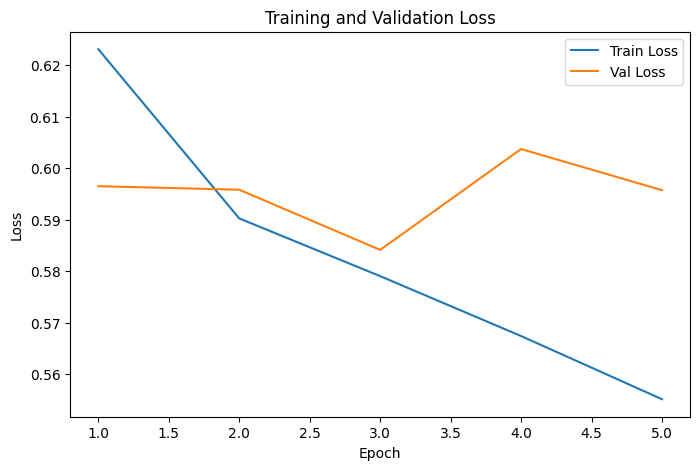

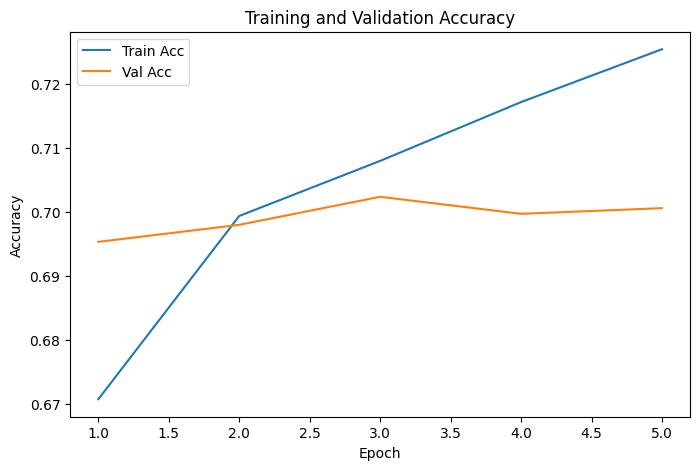

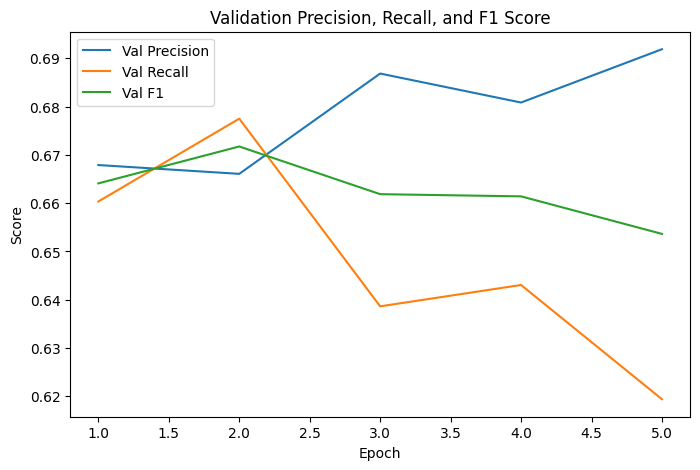

In [21]:
plot_training_history(history)

In [25]:
save_path = get_model_path("resnet34_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = ResNet34(num_classes=2, pretrained=True, freeze_backbone=False, dropout=0.3, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/resnet34_binary_target.pt


Val: 100%|██████████| 255/255 [04:25<00:00,  1.04s/it, avg_acc=0.7054, avg_loss=0.5863]


Test Results
  Loss: 0.5863
  Accuracy: 0.7054
  Precision: 0.6747
  Recall: 0.6997
  F1 Score: 0.6870


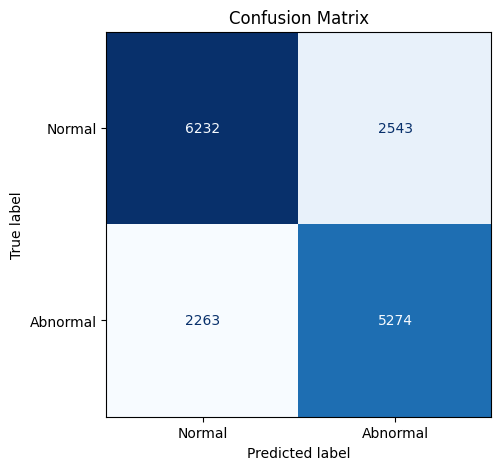

In [26]:
plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

In [27]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()  # Get the evaluation transforms (no augmentation)

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"])
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_008/images/00016972_017.png
Predicted class: abnormal
True label: normal
Probabilities: {'normal': 0.2571987509727478, 'abnormal': 0.7428012490272522}
